# Visión por Computadora I - CEIA

## Trabajo Práctico 2

Quiroga, Martin Gabriel
a2412

-----

### Objetivo
Implementar un detector de máximo enfoque sobre un video aplicando técnicas de análisis espectral similar al que utilizan las cámaras digitales modernas. El video a procesar será: "focus_video.mov".

#### 1. Se debe implementar un algoritmo que dad una imagen, o región, calcule la métrica propuesta en el paper "Image Sharpness Measure for Blurred Images in Frequency Domain" y realizar tres experimentos:
1. Medición sobre todo el frame
2. Medición sobre una ROI ubicada en el centro del frame. Area de la ROI = 5 o 10% del area total del frame.

Opcional:
Medición sobre una matriz de enfoque compuesta por un arreglo de NxM elementos rectangulares equiespaciados. N y M son valores arbitrarios, probar con varios valores 3x3, 7x5, etc... (al menos 3)

Para cada experimento se debe presentar:
- Una curva o varias curvas que muestren la evolución de la métrica frame a frame donde se vea claramente cuando el algoritmo detectó el punto de máximo enfoque.

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
video_path = "focus_video.mov"
captura = cv.VideoCapture(video_path)

# Visualizar el video
fps = int(captura.get(cv.CAP_PROP_FPS))
print(f"FPS del video: {fps}")
delay = int(600/fps)

if not captura.isOpened():
    print("Error al abrir el video")
else:
    while True:
        ret, frame = captura.read()
        if not ret:
            break
        cv.imshow("Video", frame)

        if cv.waitKey(delay) & 0xFF == ord('q'):
            break

# captura.release()
cv.destroyAllWindows()


FPS del video: 29


[]

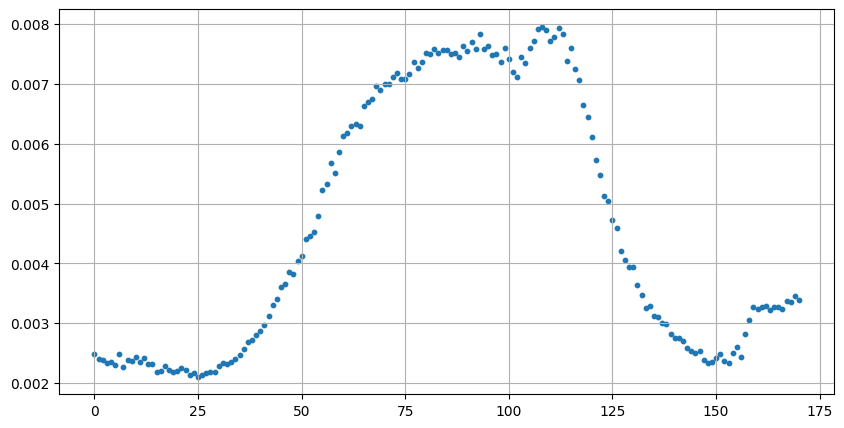

In [11]:
# Medición de sharpness(nitidez) sobre todo el frame
# Abrir el video nuevamente
captura = cv.VideoCapture(video_path)

# Obtener propiedades del video
frame_width = int(captura.get(cv.CAP_PROP_FRAME_WIDTH))   # M
frame_height = int(captura.get(cv.CAP_PROP_FRAME_HEIGHT)) # N

FM = []
while True:
    ret, frame = captura.read()
    if not ret:
        break
    gray_frame = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
    F = np.fft.fft2(gray_frame)
    Fc = np.fft.fftshift(F) # Pasos 1 y 2
    AF = np.abs(Fc) # Paso 3
    M = np.max(AF) # Paso 4
    threshold = M * 0.001
    Th = np.sum(np.where(F > threshold, 1, 0)) # Paso 5

    FM.append(Th / (frame_width * frame_height))

plt.figure(figsize=(10, 5))
plt.scatter(
    range(len(FM)),
    FM,
    s=10,
    label="Image Quality Measure (FM)",

)
# plt.plot(FM, label="Image Quality Measure (FM)")
plt.grid()
plt.plot()


#### 2. Cambiar la métrica de enfoque eligiendo uno de los algoritmos explicados en el apéndice de: Analysis of focus measure operators in shape-from-focus.